In [1]:
import numpy as np
import matplotlib.pyplot as plt

# from google.colab import drive
# drive.mount('/content/drive',force_remount = True)

## Implementazione del metodo di Gauss con pivoting parziale

L'implementazione del metodo di Gauss per la soluzione di un sistema lineare

$$Ax=b$$

può essere organizzata in 2 function

* una function per calcolare la fattorizzazione $PA=LU$
* una function che riceve i dati $A,b$, calcola la fattorizzazione di Gauss di $A$ con la prima function e risolve i due sistemi triangolari associati

$$Ax=b 
\quad\Leftrightarrow\quad PAx=Pb 
\quad\Leftrightarrow\quad LUx=Pb
\quad\Leftrightarrow\quad \left\{\begin{array}{lcl}
Ly&=& Pb\\
Ux &=& y
\end{array}\right.$$


In [2]:
# Metodo di Gauss SENZA pivoting (fattorizzazione LU "in-place")

def gauss_1loop(A):
    n, _ = A.shape
    
    # Ciclo sui passi dell'eliminazione gaussiana
    # Ad ogni passo k si annullano gli elementi sotto il pivot A[k,k]
    for k in range(n-1):
        
        # Controllo sul pivot:
        # se è troppo piccolo, il metodo può diventare instabile o fallire
        if np.abs(A[k,k]) < 1e-16:
            print('perno numericamente troppo piccolo')
            break
        
        # Calcolo dei moltiplicatori:
        #   m[i,k] = A[i,k] / A[k,k] per i = k+1,...,n-1
        # Questi coefficienti servono per annullare la colonna sotto il pivot
        A[k+1:, k] = A[k+1:, k] / A[k, k]
        
        # Aggiornamento della sottomatrice:
        #   A[i,j] = A[i,j] - m_ik * A[k,j]
        # Qui stiamo facendo TUTTE le combinazioni lineari in modo vettoriale.
        # Questo equivale al passo classico dell'eliminazione gaussiana,
        # ma scritto in forma matriciale (molto più efficiente)
        A[k+1:, k+1:] = A[k+1:, k+1:] - \
            np.reshape(A[k+1:, k], (n-k-1, 1)) @ \
            np.reshape(A[k, k+1:], (1, n-k-1))
    
    # Alla fine:
    # - la parte triangolare superiore contiene U
    # - la parte sotto la diagonale contiene i moltiplicatori (cioè L senza la diagonale)
    return A

In [3]:
from scipy.linalg import solve_triangular

# Metodo di Gauss con pivoting parziale
#  L'obiettivo è rendere l'algoritmo più stabile scegliendo, ad ogni passo,
#  il miglior pivot possibile (in valore assoluto) nella colonna corrente.

def gauss_piv(A):
    n, _ = A.shape
    
    # Vettore di permutazione:
    #   tiene traccia degli scambi di righe effettuati su A
    #   invece di costruire esplicitamente la matrice di permutazione P
    p = np.arange(n)
    
    # Fase di eliminazione (fattorizzazione LU con pivoting)
    for k in range(n-1):
        
        # Scelta del pivot:
        #  cerchiamo l'indice della riga con elemento massimo (in valore 
        #  assoluto) nella colonna k, a partire dalla riga k
        r = np.argmax(np.abs(A[k:, k]))
        
        # L'indice è relativo alla sottomatrice, quindi va traslato
        r += k
        
        # Scambio delle righe:
        #  portiamo il pivot migliore in posizione (k,k)
        A[[k,r], :] = A[[r, k], :]
        #  aggiorniamo anche il vettore di permutazione
        #  per mantenere coerenza con gli scambi fatti su A
        p[[k,r]] = p[[r, k]]
        
        # Controllo sul pivot:
        #  se troppo piccolo, il sistema può essere mal condizionato o singolare
        if np.abs(A[k, k]) < 1e-16:
            print('perno numericamente troppo piccolo')
            break
        
        # Calcolo dei moltiplicatori:
        #  servono per annullare gli elementi sotto il pivot
        A[k+1:, k] = A[k+1:, k] / A[k, k]
        
        # Aggiornamento della sottomatrice:
        #   A[i,j] = A[i,j] - m_ik * A[k,j]
        #  forma vettoriale tramite prodotto esterno
        A[k+1:, k+1:] = A[k+1:, k+1:] - \
            np.reshape(A[k+1:, k], (n-k-1, 1)) @ \
            np.reshape(A[k, k+1:], (1, n-k-1))
    
    # Output:
    # - A contiene sia L che U (in-place),
    # - p tiene traccia delle permutazioni
    return (A, p)


def solve_gauss_piv(A, b):
    # Fattorizzazione LU con pivoting
    A, p = gauss_piv(A)
    
    # Estrazione delle matrici:
    # - U = parte triangolare superiore
    # - L = parte triangolare inferiore (con diagonale unitaria implicita)
    U = np.triu(A)
    L = np.tril(A)
    
    # Applichiamo le stesse permutazioni al vettore b:
    # stiamo risolvendo PAx = Pb
    b = b[p]
    
    # Risolviamo il sistema in due passi:
    
    # 1) Ly = Pb  --> sostituzione in avanti
    y = solve_triangular(L, b, lower=True, unit_diagonal=True)
    
    # 2) Ux = y   --> sostituzione all'indietro
    x = solve_triangular(U, y)
    
    return x

## Soluzione di un sistema con il metodo di Gauss con pivoting parziale

Applicare la function del punto precedente ai dati


$$A=\begin{pmatrix}
1 &4& 5& 6\\ -1 &4& 5&8\\ 5 &-5&9&-2\\ 7&-2&0&-3
\end{pmatrix},\qquad b = \begin{pmatrix} 14\\ 20\\ -28\\ -17\end{pmatrix} $$


In [4]:
n = 4
A = np.array([[ 1,   4, 5,  6],
              [-1,   4, 5,  8],
              [ 5., -5, 9, -2],
              [ 7,  -2, 0, -3]])
b = np.array([14, 20, -28, -17])

# --- Risoluzione con la nostra implementazione ---
# Usiamo il metodo di Gauss con pivoting parziale:
# 1) fattorizzazione PA = LU
# 2) risoluzione dei due sistemi triangolari
A1 = A.copy()   # Copia per non modificare la matrice originale
x1 = solve_gauss_piv(A1, b)

print('Our Solution:\nx =', x1)


# --- Risoluzione con NumPy ---
# np.linalg.solve usa algoritmi ottimizzati (basati su LU con pivoting)
# E' la soluzione "standard" e numericamente robusta
x = np.linalg.solve(A, b)

print('Linalg Solution:\nx =', x)

Our Solution:
x = [-1.  2. -1.  2.]
Linalg Solution:
x = [-1.  2. -1.  2.]


In [5]:
import timeit

n = 100
A = np.random.randn(n, n)
b = np.random.randn(n)

# --- Confronto tempi di esecuzione ---

At = A.copy()
bt = b.copy()

# Tempo della nostra implementazione:
# Metodo di Gauss con pivoting (implementazione Python)
# 
# Più lento perché:
# - usa operazioni non completamente ottimizzate
# - overhead di Python
t3 = timeit.timeit(lambda: solve_gauss_piv(At, bt), number=10)

# Tempo della libreria NumPy:
# Usa routine ottimizzate (BLAS/LAPACK in C/Fortran)
# Molto più veloce e stabile numericamente
t1 = timeit.timeit(lambda: np.linalg.solve(A, b), number=10)

print(t3, t1)

0.0610114430000408 0.0012451560000386053


## Data filling/inpainting

In diverse situazione realistiche si può presentare il problema di recuperare un'informazione che per qualche motivo si è deteriorata o è mancante. Nel concreto, può capitare che in un set di dati memorizzato in un array, manchino delle componenti.

Assumendo che componenti adiacenti dell'array abbiano una sorta di "coerenza" tra esse, la ricostruzione dei dati mancanti può avvenire mediante la soluzione di un sistema lineare che si costruisce ragionando come segue.

> **Partendo dai dati disponibili, si vuole calcolare un nuovo vettore in cui ogni componente da ricostruire è data dalla media tra la componente che la precede e quella che la segue, mentre quelle note sono mantenute uguali.**

Esempio: sia $y\in{\mathbb R}^7$ il vettore dei dati, a cui mancano le componenti $2,3,4,6$. SI vuole calcolare il vettore $x\in{\mathbb R}^7$ tale che

$$
\begin{array}{lccccccc}
\text{INPUT:}&y_1&\color{red}{y_2}&\color{red}{y_3}&\color{red}{y_4}&y_5&\color{red}{y_6}&y_7\\
\text{OUTPUT:}&x_1&x_2&x_3&x_4&x_5&x_6&x_7
\end{array}
$$

$$\left\{
  \begin{array}{lcl}
  x_1 &=& y_1\\
  x_2 &=& \frac 1 2(x_1+x_3)\\
  x_3 &=& \frac 1 2(x_2 +x_4)\\
  x_4 &=& \frac 1 2(x_3 + x_5)\\
  x_5 &=& y_5\\
  x_6 &=& \frac 1 2 (x_5+x_7)\\
  x_7 &=& y_7
  \end{array}
  \right. \Rightarrow
  \left\{
  \begin{array}{lcl}
  x_1 &=& y_1\\
  x_1-2x_2 +x_3&=& 0\\
  x_2-2x_3+x_4 &=& 0\\
  x_3-2x_4 +x_5&=& 0\\
  x_5 &=& y_5\\
  x_5-2x_6+x_7 &=& 0\\
  x_7 &=& y_7
  \end{array}
  \right. $$
  
  Spostando sul lato sinistro delle equazioni tutte le componenti che dobbiamo calcolare otteniamo un sistema lineare.

  La matrice dei coefficienti e il termine noto del sistema qui sopra si scrivono nel modo seguente
  
  $$
  A = \begin{pmatrix}
  1 &0 &0 &0 &0 &0 &0\\
  0& 0&0 &0 & 0 &0 &0\\
  0& 0&0 &0 & 0 &0 &0\\
  0& 0&0 &0 & 0 &0 &0\\
  0& 0&0 &0 & 1 &0 &0\\
  0& 0&0 &0 & 0 &0 &0\\
  0& 0&0 &0 & 0 &0 &1
  \end{pmatrix}
 +
\begin{pmatrix}
  0 &0 &0 &0 &0 &0 &0\\
  1& -2&1 &0 & 0 &0 &0\\
  0& 1&-2 &1 & 0 &0 &0\\
  0& 0&1 &-2 & 1 &0 &0\\
  0& 0&0 &0 & 0 &0 &0\\
  0& 0&0 &0 & 1 &-2 &1\\
  0& 0&0 &0 & 0 &0 &0
  \end{pmatrix},\quad b = \begin{pmatrix} y_1\\0\\0\\0\\y_5\\0\\y_7\end{pmatrix}
 $$

**Osservazioni**
* la matrice dei coefficienti è la somma di due matrici
  * una ha tutti zeri tranne le righe con lo stesso indice delle componenti note, in cui c'è solo l'elemento diagonale unitario
  * nell'altra matrice, le righe con gli indici delle componenti note sono nulle, mentre le altre hanno 2 sulla diagonale principale e -1 sulle prime diagonali secondarie
* il termine noto ha componenti nulle in corrispondenza dei dati mancanti, mentre le altre componenti sono i dati noti.

Implementiamo il metodo sui dati del file `dati_rec.npz`.


numero totale componenti 400 
numero dati 208 
numero dati mancanti 192


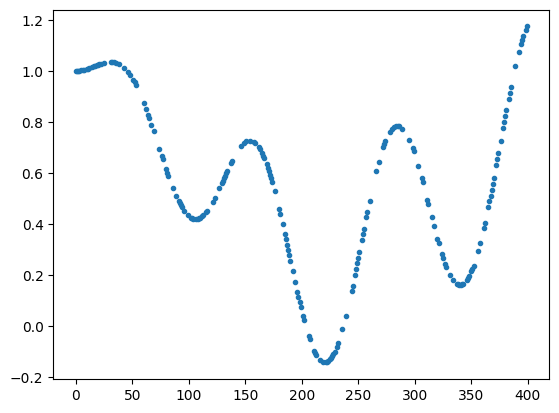

In [6]:
# --- Data filling / inpainting ---
# Obiettivo: ricostruire i dati mancanti a partire da quelli disponibili

filename = './dati_rec.npz'
dati_esperimento = np.load(filename)

# ind_ok: indici delle componenti "valide" (cioè non mancanti)
ind_ok = dati_esperimento['ind_ok']

# y_ok: valori del segnale corrispondenti agli indici validi
y_ok = dati_esperimento['y_ok']

# n: lunghezza totale del segnale originale (inclusi i dati mancanti)
n = ind_ok.size

print('numero totale componenti', n,
      '\nnumero dati', y_ok.size,
      '\nnumero dati mancanti', n - y_ok.size)

# Vettore degli indici completi (0, 1, ..., n-1)
nn = np.arange(n)

# Visualizzazione dei dati disponibili
plt.figure(2)
plt.plot(nn[ind_ok], y_ok, '.')

# --- Interpretazione ---
# Il grafico mostra solo i punti "noti" del segnale.
# Essendo presenti dati mancanti, il segnale appare discontinuo.
#
# Il problema è quindi:
# ricostruire i valori mancanti in modo coerente con quelli osservati.

In [7]:
# Costruiamo il sistema lineare per ricostruire i dati mancanti

def smoothness_function(n: int):
    # Matrice tridiagonale (tipo Laplaciano discreto 1D)
    # Serve a imporre una condizione di "regolarità" sul segnale:
    # penalizza variazioni brusche tra elementi consecutivi
    return (
        -2. * np.eye(n)
        + np.eye(n, k=-1)
        + np.eye(n, k=1)
    )

# Matrice che impone la regolarità (smoothness)
L = smoothness_function(n)

# Nei punti dove i dati sono noti (ind_ok),
# NON vogliamo imporre la regolarità ma il valore esatto.
# Quindi annulliamo le righe corrispondenti in L
L[ind_ok, :] = 0

# Costruiamo una matrice diagonale che "attiva" i vincoli sui dati noti
d = np.zeros(n)
d[ind_ok] = 1

A = np.diag(d) + L

# Termine noto:
# - zero dove i dati sono mancanti
# - y_ok dove i dati sono noti
b = np.zeros(n)
b[ind_ok] = y_ok

# Risoluzione del sistema lineare
x = np.linalg.solve(A, b)

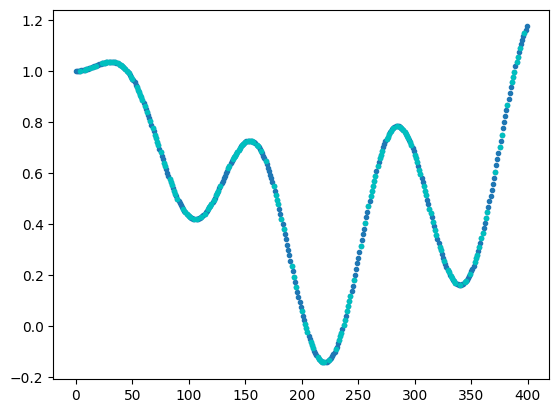

In [8]:
plt.figure(3)

# Plot della soluzione completa ricostruita
plt.plot(x, '.')

# Individuiamo gli indici dei dati mancanti
not_indok = np.logical_not(ind_ok)

# Evidenziamo SOLO i valori ricostruiti (quelli mancanti)
plt.plot(nn[not_indok], x[not_indok], '.c')

**Scelta dell'algoritmo in base alla struttura della matrice dei coefficienti**

Gli elementi non nulli della matrice dell'esempio precedente si trovano su tre diagonali: si tratta di una matrice *a banda*.

* Le matrici a banda composte da $r$ diagonali possono essere memorizzate su $r$ vettori $\to$ **risparmo di memoria**
* La fattorizzazione di matrici a banda può essere ottimizzata per evitare calcoli inutili $\to$ **risparmio di complessità**

Scipy contiene una function che implementa la [soluzione di un sistema per matrici a banda](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_banded.html#scipy.linalg.solve_banded).

Richiede che la matrice venga memorizzata in forma compatta in un array 2D le cui righe contengono le diagonali della banda.
$$
\begin{pmatrix}
  1 &\color{blue}0 &0 &0 &0 &0 &0\\
  \color{red}1& -2&\color{blue}1 &0 & 0 &0 &0\\
  0& \color{red}1&-2 &\color{blue}1 & 0 &0 &0\\
  0& 0&\color{red}1 &-2 & \color{blue}1 &0 &0\\
  0& 0&0 &\color{red}0 & 1 &\color{blue}0 &0\\
  0& 0&0 &0 & \color{red}1 &-2 &\color{blue}1\\
  0& 0&0 &0 & 0 &\color{red}0 &1
  \end{pmatrix}, \begin{pmatrix}*&\color{blue}0 &\color{blue} 1&\color{blue}1&\color{blue}1 &\color{blue}0&\color{blue}1\\
  1&-2&-2&-2&1&-2&1\\
  \color{red}1&\color{red}1&\color{red}1& \color{red}0&\color{red}1&\color{red}0&* \end{pmatrix}
 $$

In [9]:
# Costruzione vettorizzata della matrice a banda (forma diagonale compatta)

# Diagonale principale:
# - normalmente vale -2 (tipo Laplaciano discreto)
# - nei punti con dato noto (ind_ok) mettiamo 1 --> imponiamo x_i = dato
d1 = -2. * np.ones(n)
d1[ind_ok] = 1.

# Diagonali secondarie (sopra e sotto):
# - normalmente valgono 1
# - nei punti noti le azzeriamo --> nessuna interazione con i vicini
d2 = np.ones(n)
d2[ind_ok] = 0.

# Matrice in formato "a bande" (3 diagonali: sopra, centrale, sotto)
Adiag = np.zeros((3, n))

# Diagonale superiore (shiftata a destra)
Adiag[0, 1:] = d2[:-1]
# Diagonale inferiore (shiftata a sinistra)
Adiag[2, :-1] = d2[1:]
# Diagonale principale
Adiag[1, :] = d1

In [10]:
# Risoluzione del sistema sfruttando la struttura a banda
from scipy.linalg import solve_banded

# (1,1) --> 1 diagonale sopra e 1 sotto (matrice tridiagonale)
xband = solve_banded((1,1), Adiag, b)

# Confronto con la soluzione ottenuta con matrice piena
# (devono coincidere a meno di errori numerici)
print(np.linalg.norm(x - xband))

0.0


In [11]:

# Confronto tempi di esecuzione
import timeit

# Metodo generico (matrice piena)
t1 = timeit.timeit(lambda: np.linalg.solve(A, b), number=50)

# Metodo ottimizzato per matrici a banda
t2 = timeit.timeit(lambda: solve_banded((1,1), Adiag, b), number=50)

print(t1, t2)

# Osservazione:
# solve_banded è molto più veloce perché sfrutta la struttura sparsa:
# costo ~ O(n) invece di O(n^3) del metodo generico.

0.13030345399999987 0.0023984370000107447


## Compressione/decompressione lossy di un'immagine con tecniche di diffusione.

L'idea alla base del data filling è utilizzata in molti contesti differenti, per esempio in alcune tecniche recenti di compressione delle immagini.

Premessa:
* immagine digitale in *scala di grigi = matrice*
* ad una matrice possiamo associare il vettore ottenuto riordinando le componenti per righe (come avviene in memoria in Python e C) o per colonne (Matlab e Fortran).

La fase di compressione è la più costosa e utilizza tecniche di ottimizzazione numerica per selezionare quali pixel dell'immagine saranno salvati nella sua versione compressa.

Nella fase di decompressione, si costruisce una nuova immagine in cui i pixel salvati nel formato compresso sono mantenuti, mentre gli altri sono calcolati in modo che siano la media tra i 4 pixel più vicini in verticale e orizzontale.
$$ \begin{array}{cccccc}
x_{i-1,j-1}&x_{i-1,j}&x_{i-1,j+1}\\
x_{i,j-1}&x_{i,j}&x_{i,j+1}\\
x_{i+1,j-1}&x_{i+1,j}&x_{i+1,j+1}\\
\end{array}$$

Se $x_{ij}$ è uno dei pixel mancanti, viene ricostruito in modo che
$$x_{ij} = \frac 1 4 (x_{i-1,j} + x_{i+1,j} + x_{i,j-1} + x_{i,j+1}) $$

Come nel caso 1D, anche qui il problema si riduce alla soluzione di un sistema lineare, di dimensioni pari al numero dei pixel in cui la matrice ha molti elementi nulli.

L'immagine decompressa non sarà uguale a quella iniziale, ma se la fase di compressione è stata realizzata secondo opportuni criteri, la differenza visiva sarà minima.


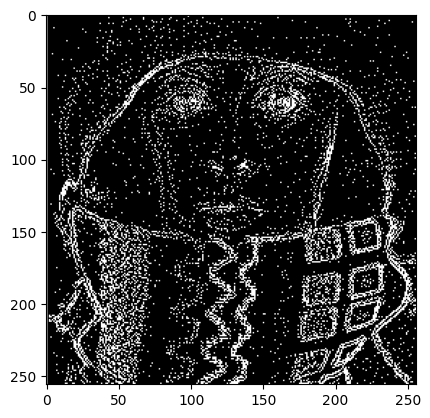

In [12]:
from scipy.sparse import diags_array
from scipy.sparse.linalg import spsolve
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

# --- Problema ---
# Ricostruzione di un segnale 2D (o vettorializzato) con dati mancanti
# usando una matrice sparsa a 5 diagonali (stencil tipo Laplaciano)

# Caricamento dati
filename = 'trui.npz'
dati_trui = np.load(filename)

y_ok   = dati_trui['y_ok']     # valori noti del segnale
ind_ok = dati_trui['ind_ok']   # indici dei valori noti
N      = dati_trui['N']        # dimensione griglia (N x N)
n      = ind_ok.size           # dimensione vettorializzata

# Visualizzazione della maschera dei dati noti
plt.imshow(np.reshape(ind_ok, (N, N)), cmap='gray')


# --- Costruzione della matrice a bande ---
# Stencil a 5 diagonali:
# centro + 4 direzioni (su, giù, sinistra, destra)

diag1 = np.ones(n)

# Dove ho dati noti, non voglio applicare lo smoothing
# quindi annullo il contributo delle connessioni
diag1[ind_ok] = 0


# Diagonale principale
# -3 o -4 a seconda della posizione (bordo o interno)
# + 1 nei punti con dato noto (vincolo forte x_i = y_i)
diag0 = -4 * np.ones(n)
diag0[:N] = -3        # bordo superiore
diag0[n-N:] = -3      # bordo inferiore
diag0[ind_ok] = 1     # vincolo sui dati noti


# --- Assemblaggio delle diagonali ---
# Ordine offsets:
# -N → sopra (verticale)
# -1 → sinistra
#  0 → diagonale principale
# +1 → destra
# +N → sotto

diagonals = [
    diag1[N:],   # -N
    diag1[1:],   # -1
    diag0,       # 0
    diag1[:-1],  # +1
    diag1[:-N]   # +N
]


# --- Matrice sparsa ---
# Costruzione efficiente della matrice del sistema
A = diags_array(diagonals, offsets=[-N, -1, 0, 1, N], shape=(n, n))

# Conversione in formato CSR (Compressed Sparse Row)
# ottimizzato per la risoluzione di sistemi lineari
A = csr_matrix(A)


# --- Termine noto ---
# vincolo: nei punti noti imponiamo y_ok
b = np.zeros(n)
b[ind_ok] = y_ok

# maschera complementare (punti mancanti)
not_indok = np.logical_not(ind_ok)


# --- Risoluzione del sistema sparso ---
# spsolve sfrutta la struttura sparsa della matrice
# molto più efficiente rispetto a solver per matrici dense
x_dec = spsolve(A, b)

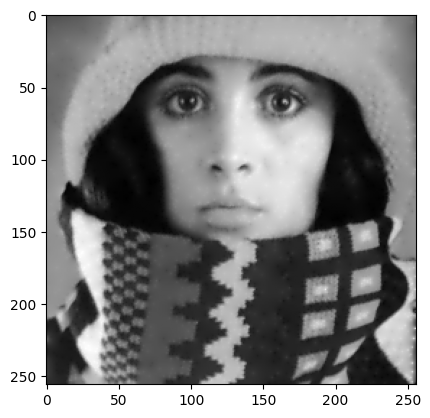

In [13]:
# Visualizzazione della ricostruzione in scala di grigi
dec = np.reshape(x_dec,(N,N))
plt.imshow(dec,cmap='gray')

In [14]:
# Numero di pixel totali e originali
(256**2, y_ok.size)

# Sono rimasti solamente ~9k pixel su ~65k totali
# --> forte riduzione dell’informazione disponibile

# Interpretazione:
# il problema può essere visto come una forma di
# "ricostruzione/inpainting" con dati incompleti

# Nota:
# tecnicamente NON è compressione classica,
# ma può essere vista come una rappresentazione sparsa dell’informazione

(65536, 9136)

## Esperimento numerico con la matrice di Wilkinson

Consideriamo la seguente matrice $n\times n$ (matrice di Wilkinson)

$$ A = \begin{pmatrix}
1 &   & & & & & 1\\
-1& 1 & & & & & 1\\
-1&-1& 1& & & & 1\\
\vdots & & &\ddots & & &\vdots\\
-1& -1 & -1 &        && 1& 1\\
-1& -1&-1 & \cdots & \cdots &-1&1
\end{pmatrix}$$

Procedura:
1. Scrivere una function che, dato un intero $n$, restituisce la matrice di Wilkinson di dimensione $n$.
2. Costruire un problema test relativo alla matrice di Wilkinson di dimensione 10 che abbia come soluzione il vettore di tutti 1. Calcolare la soluzione del sistema con la funzione `linalg.solve` e confrontare la soluzione calcolata con la soluzione esatta.
3. Ripetere l'esperimento con $n=100$.
4. Ricalcolare la matrice con $n=10$, applicare la fattorizzazione $LU$ di Gauss e stampare la matrice $U$.

In [15]:
import numpy as np

# 1) Matrice di Wilkinson
def wilkinson(n: int):
    # Triangolo inferiore con -1 sotto la diagonale
    M = np.tril(-np.ones((n, n)), -1)
    # Aggiungo la diagonale principale (identità)
    M += np.eye(n)
    # Modifico l'ultima colonna (eccetto ultima riga)
    M[:-1, n-1] = 1

    return M


# 2) Generazione del problema test
def gen_problem(n: int):
    W = wilkinson(n)     # matrice del sistema
    x = np.ones(n)       # soluzione esatta nota
    b = W @ x            # termine noto costruito a partire da x
    return W, b, x


# 3) Risoluzione e verifica errore con n=100
n = 100

W, b, x = gen_problem(n)

# Risoluzione del sistema lineare
x1 = np.linalg.solve(W, b)

# Soluzione numerica ottenuta
print('(n=100) Soluzione x =', x1)

# Errore rispetto alla soluzione esatta
print('(n=100) Errore relativo =', np.linalg.norm(x - x1))


# 4) Ricalcolare la matrice con n=10, applicare la fattorizzazione LU di Gauss e stampare la matrice U
n = 10

W, b, x = gen_problem(n)

# Fattorizzazione
PA, p = gauss_piv(W.copy())

# Estrazione L e U
U = np.triu(PA)
L = np.tril(PA, -1) + np.eye(n)

# Matrice di permutazione P
P = np.eye(n)[p]  # applica permutazione alle righe

# Stampa matrice U
print('(n=10) Matrice triangolare superiore U =\n', U)

# Verifica: PA ≈ LU
print("(n=10) Errore ||PA - LU|| =", np.linalg.norm(P @ W - L @ U))

(n=100) Soluzione x = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1.]
(n=100) Errore relativo = 6.782329983125268
(n=10) Matrice triangolare superiore U =
 [[  1.   0.   0.   0.   0.   0.   0.   0.   0.   1.]
 [  0.   1.   0.   0.   0.   0.   0.   0.   0.   2.]
 [  0.   0.   1.   0.   0.   0.   0.   0.   0.   4.]
 [  0.   0.   0.   1.   0.   0.   0.   0.   0.   8.]
 [  0.   0.   0.   0.   1.   0.   0.   0.   0.  16.]
 [  0.   0.   0.   0.   0.   1.   0.   0.   0.  32.]
 [  0.   0.   0.   0.   0.   0.   1.   0.   0.  64.]
 [  0.   0.   0.   0.   0.   0.   0.   1.   0. 128.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   1. 256.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0. 512.]]
(n=10) Errore ||PA - LU|| = 0.0


## Fattorizzazione di Cholesky per matrici simmetriche definite positive

Una matrice è simmetrica quando coincide con la sua trasposta. Gli autovalori di una matrice simmetrica sono reali. Quando tutti gli autovalori di una matrice sono positivi, la matrice si dice **definita positiva**.

Le matrici simmetriche definite positive si possono fattorizzare nella forma

$$A = {\mathcal L}{\mathcal L}^T $$

dove ${\mathcal L}$ è una matrice triangolare inferiore con elementi diagonali positivi.

L'algoritmo di Cholesky si può ricavare sfruttando le uguaglianze matriciali (si parla di metodo di pavimentazione).

Esempio ($n=3$)

$$\begin{array}{lcl}
\begin{pmatrix}
a_{11}& a_{21}& a_{31}\\
a_{21}&a_{22}&a_{23}\\
a_{31}&a_{32}& a_{33}
\end{pmatrix} &=&\begin{pmatrix} l_{11} & &\\ l_{21} & l_{22} &\\ l_{31} & l_{32} &l_{33}\end{pmatrix}\begin{pmatrix} l_{11} & l_{21}&l_{31} \\ & l_{22} & l_{32}\\ & & l_{33} \end{pmatrix}\\
&=& \begin{pmatrix}
l_{11}^2 & l_{21}l_{11} & l_{31}l_{11}\\
l_{21}l_{11}& l_{21}^2l_{22}^2 & l_{21}l_{31}+l_{32}l_{22}\\
l_{31}l_{11}& l_{31}l_{21}+l_{32}l_{22} & l_{31}^2+l_{32}^2+l_{33}^2
\end{pmatrix}
\end{array}$$

considerando le uguaglianze sui singoli elementi della prima colonna si ottiene

$$
\begin{array}{lcl}
a_{11} = l_{11}^2 \rightarrow l_{11} = \sqrt{a_{11}}\\
a_{21} = l_{21}l_{11}\rightarrow l_{21} = \frac{a_{21}}{l_{11}}\\
a_{31} = l_{31}l_{11}\rightarrow l_{31} = \frac{a_{31}}{l_{11}}
\end{array}
$$

Le uguaglianze qui sopra vanno interpretate in modo sequenziale e permettono di calcolare tutti gli elementi della prima colonna di $\mathcal L$. Questo è il primo passo dell'algoritmo di Cholesky.

Il secondo passo procede in modo analogo, considerando le uguaglianze sulle componenti della seconda colonna

$$\begin{array}{lcl}
a_{22} &=& l_{21}^2+l_{22}^2\rightarrow l_{22} = \sqrt{a_{22}-l_{21}^2}\\
a_{32} &=& l_{31}l_{21}+l_{32}l_{22} \rightarrow l_{32} = \frac{a_{32}-l_{31}l_{21}}{l_{22}}
\end{array}$$

Il terzo e ultimo passo dell'algoritmo permette di calcolare l'ultimo elemento

$$a_{33} =   l_{31}^2+l_{32}^2+l_{33}^2\rightarrow l_{33} = \sqrt{a_{33} - l_{31}^2-l_{32}^2}$$

**Complessità dell'algoritmo di Cholesky:** ${\mathcal O}(n^3/6)$

## Soluzione di un sistema con matrice di Cholesky

$$Ax=b$$

dove $A$ è simmetrica definita positiva.
* Calcolare la fattorizzazione $A={\mathcal L}{\mathcal L}^T$
* Risolvere i sistemi triangolari associati ottenuti mediante la sostituzione

$$
Ax=b \quad\Leftrightarrow\quad {\mathcal L}{\mathcal L}^Tx = b\quad\Leftrightarrow\quad\left\{
\begin{array}{lcl}{\mathcal L}y&=&b\\ {\mathcal L}^Tx &=& y \end{array}   \right.
$$

In [16]:
from scipy.linalg import cholesky
#def chol_solve(A,b):



In [17]:
n = 10
a = np.random.randn(n)

# =========================================
# Trasformazione di Householder (1ª riflessione)
# 
# Obiettivo: azzerare tutte le componenti di a
#            tranne la prima, preservando la norma
# =========================================

# 1) Norma del vettore originale
sigma = np.linalg.norm(a)
print('Norma vettore originale =', sigma)

# 2) Costruzione del vettore di Householder v
v = a.copy()

# Si usa sigma per costruire la riflessione stabile numericamente
# (evita cancellazione numerica)
v[0] += sigma

# v come vettore colonna
v = v.reshape(n, 1)

# 3) Costante di normalizzazione
alpha = (v.T @ v) / 2

# 4) Matrice di Householder
# H = I - 2 * (v v^T) / (v^T v)
H = np.eye(n) - (v @ v.T) / alpha

# =========================================
# Applicazione della trasformazione
# =========================================

print('Vettore riflesso =\n', H @ a)

# Output atteso:
# [ -||a||, 0, 0, ..., 0 ]
# (zeri numerici ~ precisione macchina)

# =========================================
# Proprietà della matrice di Householder
# =========================================

# Ortogonalità: H^T H = I
print('Ortogonalità:', np.linalg.norm(np.eye(n) - H @ H.T))

# Simmetria: H = H^T
print('Simmetria:', np.linalg.norm(H - H.T))

# Auto-inversa: H^-1 = H
print('Auto-inversa:', np.linalg.norm(H - np.linalg.inv(H)))

Norma vettore originale = 2.6934059898244156
Vettore riflesso =
 [-2.69340599e+00  4.16333634e-17 -8.32667268e-17 -6.93889390e-18
  4.16333634e-17 -6.93889390e-18  2.77555756e-16 -1.38777878e-17
 -1.38777878e-17  2.22044605e-16]
Ortogonalità: 3.978930576021251e-16
Simmetria: 0.0
Auto-inversa: 5.005539512721135e-16


Si stà costruendo una **riflessione ortogonale** che:
- prende un vettore $a$
- lo allinea con l’asse $e_1$
- elimina tutte le componenti sotto la prima.

Formula chiave da ricordare:
$$
H = I - 2 \frac{vv^T}{v^T v}
$$

Proprietà fondamentali:
$$
\begin{aligned}
H^T H &= I \quad &\text{(ortogonale)} \\
H^T &= H \quad &\text{(simmetrica)} \\
H^{-1} &= H \quad &\text{(auto-inversa)}
\end{aligned}
$$